# Лабораторная работа 13

Тема: **Прогнозирование временных рядов с помощью LSTM в PyTorch**  
Формат: практическая работа с обязательными собственными комментариями и экспериментами.

> Этот ноутбук оформлен как задание, а не как готовый отчёт.  
> Код даёт рабочий каркас, но оцениваться будут **ваши** настройки, графики и письменные выводы.  
> Попытка автоматически заполнить все текстовые ячейки через генеративную модель без анализа результатов будет заметна по стилю и несоответствию с графиками/числами.


## 1. Ваше начальное понимание временных рядов и LSTM

Перед запуском кода сформулируйте (8–12 предложений):

1. Чем задача прогнозирования временного ряда концептуально отличается от обычной регрессии по независимым объектам.  
2. Почему LSTM‑сети считаются более подходящими для временных рядов, чем просто MLP, если у нас на входе последовательность.  
3. Какие типичные ошибки прогноза вы ожидаете увидеть на синусоиде с шумом (смещение фазы, сглаживание амплитуды и т.п.).

Пишите своими словами, без попытки угадать «официальные» формулировки.


In [1]:
intro_text = """1)Задача прогнозирования времененного ряда концептуально отличается от обычной реграссии по независимым объектам тем, что есть зависимость данных от времени и их порядка.
В обычной регрессии каждый объект считается независимым, поэтому модель  не учитывает то, что следующие значения могут зависеть от предыдущих.
Временной ряд, наоборот, имеет структуру, значение времени зависит от предыдущего времени.
Также задачи отличаются по цели, во временных рядах задачей является спрогнозировать будущие значения, а в обычной регрессии выявляются взаимосвязи.

2)В LSTM есть особенность - система «врат» (gates).
Благодаря ей LSTM может запоминать информацию о предыдущих значениях и использовать её при обработке новых данных длительное время.
Также LSTM способна фиксировать нелинейные зависимости и создавать сложные шаблоны.
А обычная регрессия работает с входом без памяти.

3)На синусоиде с шумом можно ожидать смещение фазы, сглаживание аплитуды.
"""
print(intro_text)

1)Задача прогнозирования времененного ряда концептуально отличается от обычной реграссии по независимым объектам тем, что есть зависимость данных от времени и их порядка.
В обычной регрессии каждый объект считается независимым, поэтому модель  не учитывает то, что следующие значения могут зависеть от предыдущих.
Временной ряд, наоборот, имеет структуру, значение времени зависит от предыдущего времени.
Также задачи отличаются по цели, во временных рядах задачей является спрогнозировать будущие значения, а в обычной регрессии выявляются взаимосвязи.

2)В LSTM есть особенность - система «врат» (gates).
Благодаря ей LSTM может запоминать информацию о предыдущих значениях и использовать её при обработке новых данных длительное время.
Также LSTM способна фиксировать нелинейные зависимости и создавать сложные шаблоны.
А обычная регрессия работает с входом без памяти.

3)На синусоиде с шумом можно ожидать смещение фазы, сглаживание аплитуды.



## 2. Импорт библиотек и генерация временного ряда

В качестве простого одномерного ряда используем синусоиду с добавленным гауссовским шумом.


Устройство: cuda


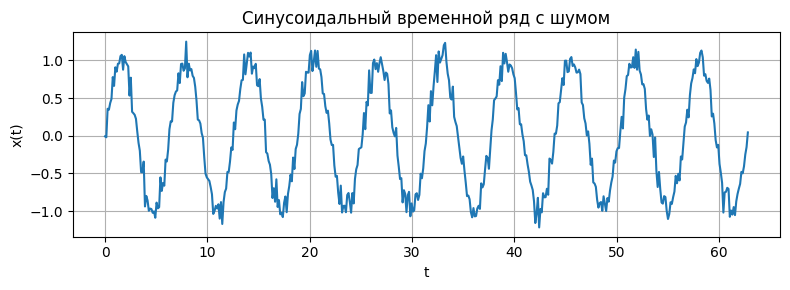

In [2]:
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

MY_SEED = 22
np.random.seed(MY_SEED)
torch.manual_seed(MY_SEED)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)

# Генерация синусоиды с шумом
n_points = 500
t = np.linspace(0, 20 * np.pi, n_points)
signal = np.sin(t) + 0.1 * np.random.randn(n_points)

plt.figure(figsize=(8, 3))
plt.plot(t, signal)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Синусоидальный временной ряд с шумом")
plt.grid(True)
plt.tight_layout()
plt.show()

### Мини‑комментарий по ряду

Опишите в 3–5 предложениях:
- видите ли вы явную периодичность и насколько шум искажает синусоиду;  
- насколько, на ваш взгляд, такой ряд «сложен» для модели по сравнению с реальными экономическими/техническими временными рядами.


In [3]:
series_comment = """На графике наблюдается явная периодичность.
Линия пооднимается и опускается примерно с одинаковым шагом, повторая синусоиду.
Однако, шум искажает форму, появляются отклонения, которые нарушают "идеальность" синусоиды, но в целом поведение хорошо сохранется на всем временном ряде.

Я думаю, что такой ряд не сложен для модели, так как поведение хорошо сохраняется.
В реальным экономических/техническим временных рядах обычно появляются более сильные скачки, смены, поэтому они будут труднее ддля прогназирования, чем данная синусоида.

"""
print(series_comment)

На графике наблюдается явная периодичность.
Линия пооднимается и опускается примерно с одинаковым шагом, повторая синусоиду.
Однако, шум искажает форму, появляются отклонения, которые нарушают "идеальность" синусоиды, но в целом поведение хорошо сохранется на всем временном ряде.

Я думаю, что такой ряд не сложен для модели, так как поведение хорошо сохраняется.
В реальным экономических/техническим временных рядах обычно появляются более сильные скачки, смены, поэтому они будут труднее ддля прогназирования, чем данная синусоида.




## 3. Нормализация и построение окон (скользящее окно)

Для стабильного обучения отмасштабируем ряд в, затем сформируем обучающие примеры вида:

- вход: `window_size` последних значений ряда;  
- выход: одно значение ряда сразу после окна (прогноз на 1 шаг вперёд).


In [4]:
scaler = MinMaxScaler(feature_range=(0, 1))
signal_scaled = scaler.fit_transform(signal.reshape(-1, 1)).flatten()

def create_windows(series, window_size):
    X = []
    y = []
    for i in range(len(series) - window_size):
        X.append(series[i:i+window_size])
        y.append(series[i+window_size])
    return np.array(X), np.array(y)

window_size = 20  # при своих экспериментах обязательно поменяйте и сравните
X_all, y_all = create_windows(signal_scaled, window_size)

print("Форма X_all:", X_all.shape)  # (n_samples, window_size)
print("Форма y_all:", y_all.shape)

Форма X_all: (480, 20)
Форма y_all: (480,)


Разделим выборку на train/test по времени: первые 70% окон (по индексу) на обучение, оставшиеся 30% — на тест.


In [5]:
train_size = int(0.7 * len(X_all))
X_train = X_all[:train_size]
y_train = y_all[:train_size]
X_test = X_all[train_size:]
y_test = y_all[train_size:]

print("Размер train:", X_train.shape)
print("Размер test :", X_test.shape)

Размер train: (336, 20)
Размер test : (144, 20)


Создадим `Dataset`/`DataLoader`. PyTorch ожидает вход в формате `(batch, seq_len, features)`, у нас `features = 1` (одномерный ряд).


In [6]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)  # (n, T, 1)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)  # (n, 1)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset = TimeSeriesDataset(X_test, y_test)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Кол-во батчей в train_loader:", len(train_loader))

Кол-во батчей в train_loader: 11


### Вопрос про размер окна

Ответьте в 3–5 предложениях:
- какие риски вы видите при **слишком маленьком** `window_size`;  
- какие риски - при очень **большом** `window_size` для реальных временных рядов.


In [7]:
window_comment = """При слишком маленьком window_size у модели ограничен контекст, поэтому модели тяжело учитывать долгосрочные зависимости.
Это может приводить к плохому обобщению трендов, качество прогнозов может снизиться.

Очень большое значение window_size может замедлить обучение, увеличить память.
Также в окно попадает много ненужной, устаревшей информации, которая может быть неполезной, в связи с чем возникнет риск переобучения.
"""
print(window_comment)

При слишком маленьком window_size у модели ограничен контекст, поэтому модели тяжело учитывать долгосрочные зависимости.
Это может приводить к плохому обобщению трендов, качество прогнозов может снизиться.

Очень большое значение window_size может замедлить обучение, увеличить память.
Также в окно попадает много ненужной, устаревшей информации, которая может быть неполезной, в связи с чем возникнет риск переобучения.



## 4. Архитектура LSTM‑модели для прогноза

Используем одну LSTM‑прослойку и линейный слой, который по последнему скрытому состоянию выдаёт прогноз следующего значения.


In [8]:
input_size = 1
hidden_size = 32  # попробуйте другие значения при выполнении работы
num_layers = 1
output_size = 1

class LSTMForecaster(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        last_hidden = h_n[-1]  # (B, H)
        prediction = self.fc(last_hidden)  # (B, 1)
        return prediction

model = LSTMForecaster(input_size, hidden_size, num_layers, output_size).to(device)
print(model)

LSTMForecaster(
  (lstm): LSTM(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


### Мини‑комментарий по архитектуре

Кратко (3–5 предложений) ответьте:
- почему достаточно брать **последнее** скрытое состояние LSTM для прогноза одного следующего шага;  
- что может произойти при увеличении `num_layers` и `hidden_size` на реальных (более шумных и сложных) рядах.


In [9]:
arch_comment = """Для прогноза одного следующего шага достаточно брать последнее скрытое состояние,потому что оно содержит всю необходимую информацию о последовательности данных, которая нужна для предсказания текущего шага.
То есть в нем содержится весь контекстный ряд, в котором есть все важные зависимости, а потом линейный слой преобразует их в итоговое значение.

При увеличении num_layers и hidden_size у модели появляется риск переообучения, но у модели появляется возможность захватытвать более сложные зависимости.
Помимо этого увеличивается время обучения, вычислительные затраты.

"""
print(arch_comment)

Для прогноза одного следующего шага достаточно брать последнее скрытое состояние,потому что оно содержит всю необходимую информацию о последовательности данных, которая нужна для предсказания текущего шага.
То есть в нем содержится весь контекстный ряд, в котором есть все важные зависимости, а потом линейный слой преобразует их в итоговое значение.

При увеличении num_layers и hidden_size у модели появляется риск переообучения, но у модели появляется возможность захватытвать более сложные зависимости.
Помимо этого увеличивается время обучения, вычислительные затраты.




## 5. Обучение: функция потерь, оптимизатор, цикл

Используем MSE (среднеквадратичную ошибку) и оптимизатор Adam.


In [10]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total = 0
    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)
        total += X_batch.size(0)

    return total_loss / total

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            total_loss += loss.item() * X_batch.size(0)
            total += X_batch.size(0)
    return total_loss / total

num_epochs = 150  # в своей работе попробуйте и другое число эпох
train_losses = []
test_losses = []

for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss = evaluate(model, test_loader, criterion, device)

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Эпоха {epoch}/{num_epochs}: train_loss={train_loss:.6f}, test_loss={test_loss:.6f}")

Эпоха 1/150: train_loss=0.272404, test_loss=0.203985
Эпоха 10/150: train_loss=0.023704, test_loss=0.018321
Эпоха 20/150: train_loss=0.003053, test_loss=0.002711
Эпоха 30/150: train_loss=0.002603, test_loss=0.002019
Эпоха 40/150: train_loss=0.002361, test_loss=0.001952
Эпоха 50/150: train_loss=0.002335, test_loss=0.001954
Эпоха 60/150: train_loss=0.002387, test_loss=0.001908
Эпоха 70/150: train_loss=0.002313, test_loss=0.001939
Эпоха 80/150: train_loss=0.002334, test_loss=0.001928
Эпоха 90/150: train_loss=0.002355, test_loss=0.002100
Эпоха 100/150: train_loss=0.002466, test_loss=0.001962
Эпоха 110/150: train_loss=0.002535, test_loss=0.002071
Эпоха 120/150: train_loss=0.002264, test_loss=0.002010
Эпоха 130/150: train_loss=0.002607, test_loss=0.002389
Эпоха 140/150: train_loss=0.002347, test_loss=0.002128
Эпоха 150/150: train_loss=0.002331, test_loss=0.001968


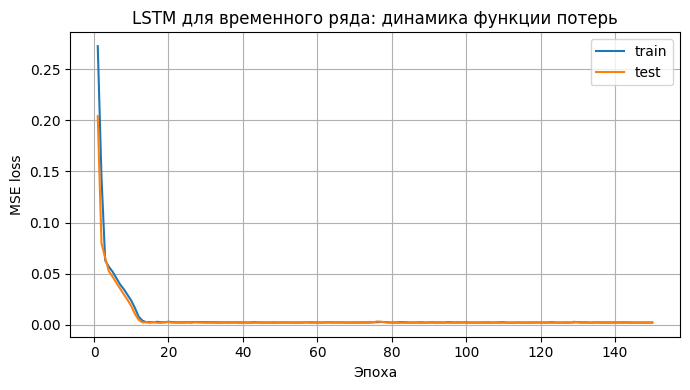

Финальные значения: train_loss=0.002331, test_loss=0.001968


In [11]:
epochs_arr = np.arange(1, num_epochs + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs_arr, train_losses, label="train")
plt.plot(epochs_arr, test_losses, label="test")
plt.xlabel("Эпоха")
plt.ylabel("MSE loss")
plt.title("LSTM для временного ряда: динамика функции потерь")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Финальные значения: train_loss={train_losses[-1]:.6f}, test_loss={test_losses[-1]:.6f}")

### Анализ кривых обучения

Опишите (6–8 предложений):
- есть ли заметный разрыв между train и test loss к концу обучения;  
- похоже ли поведение на **устойчивое приближение** к некоторому уровню ошибки;  
- совпадает ли порядок величины ошибки с тем, что вы ожидали в начале работы.


In [12]:
loss_comment = """К концу обучения нету заметного разрыв между train и test loss.
Кривые на протяжении всего обучения идут рядом друг с другом.
Более того ошибка на тесте даже меньше, чем на обучении.
Обучение похоже на устойчивое.
После 12-13 эпохи происходит снижение к минимальному числу потерь, а далее обучение стабилизируется.
Далее обучение не улучшается, появляются небольшие колебания.
Потери 0.002334 и 0.001928 выглядят достаточно маленькими, что в целом я и ожидала.
В целом архитектура подобрана правильно, признаков переобучения нет, график стабильный.

"""
print(loss_comment)

К концу обучения нету заметного разрыв между train и test loss.
Кривые на протяжении всего обучения идут рядом друг с другом.
Более того ошибка на тесте даже меньше, чем на обучении.
Обучение похоже на устойчивое.
После 12-13 эпохи происходит снижение к минимальному числу потерь, а далее обучение стабилизируется.
Далее обучение не улучшается, появляются небольшие колебания.
Потери 0.002334 и 0.001928 выглядят достаточно маленькими, что в целом я и ожидала.
В целом архитектура подобрана правильно, признаков переобучения нет, график стабильный.




## 6. Прогноз на один шаг вперёд (по всей тестовой части)

Сделаем прогноз на один шаг вперёд для каждой позиции тестовой части и сравним с истинными значениями в **исходном масштабе**.


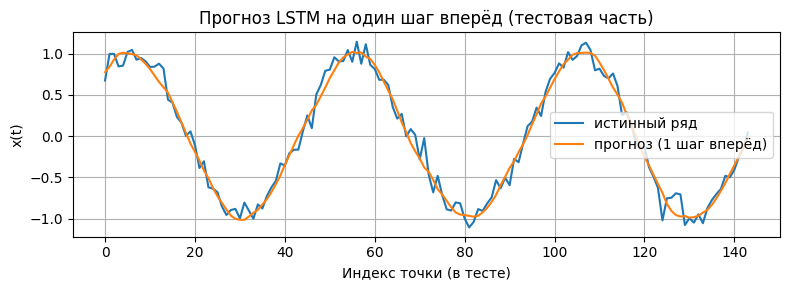

In [13]:
model.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).unsqueeze(-1).to(device)
    preds_scaled = model(X_test_tensor).cpu().numpy().flatten()

y_test_scaled = y_test
y_test_orig = scaler.inverse_transform(y_test_scaled.reshape(-1, 1)).flatten()
preds_orig = scaler.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()

plt.figure(figsize=(8, 3))
plt.plot(range(len(y_test_orig)), y_test_orig, label="истинный ряд")
plt.plot(range(len(preds_orig)), preds_orig, label="прогноз (1 шаг вперёд)")
plt.xlabel("Индекс точки (в тесте)")
plt.ylabel("x(t)")
plt.title("Прогноз LSTM на один шаг вперёд (тестовая часть)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Визуальная оценка прогноза на один шаг

Ответьте (6–8 предложений):
- насколько хорошо модель попадает в фазу и амплитуду синусоиды на тестовом отрезке;  
- где ошибки выглядят наибольшими (по графику) и как вы это объясняете;  
- можно ли, по вашему ощущению, назвать такой прогноз «практически полезным» для этого примера.


In [14]:
one_step_comment = """Модель очень хорошо попадает в фазу и амплитуду синусоиды на тестовом отрезке.
Кривая прогноза почти точно повторяет форму истинного ряда на все отрезке.
Пики и впадины совпадают по времени, значение близкие друг к другу.
Наибольшими ошибки выглядят в максимумах и минимумах.
Это можно объяснить тем, что в этих местах даже небольшая ошибка по фазе или сглаживание приводит к заметной разнице по значению.
По моему ощущению,  такой прогноз можно назвать "практически полезным" для этого примера.
Он дает хорошие значение на 1 шаг вперед и передает динамику ряда.
"""
print(one_step_comment)

Модель очень хорошо попадает в фазу и амплитуду синусоиды на тестовом отрезке.
Кривая прогноза почти точно повторяет форму истинного ряда на все отрезке.
Пики и впадины совпадают по времени, значение близкие друг к другу.
Наибольшими ошибки выглядят в максимумах и минимумах.
Это можно объяснить тем, что в этих местах даже небольшая ошибка по фазе или сглаживание приводит к заметной разнице по значению.
По моему ощущению,  такой прогноз можно назвать "практически полезным" для этого примера.
Он дает хорошие значение на 1 шаг вперед и передает динамику ряда.



## 7. Многошаговый авторегрессионный прогноз

Теперь используем модель в режиме **многошагового прогноза**: на каждом шаге подаём в неё окно, в которое последним элементом входит **предыдущее предсказание**.


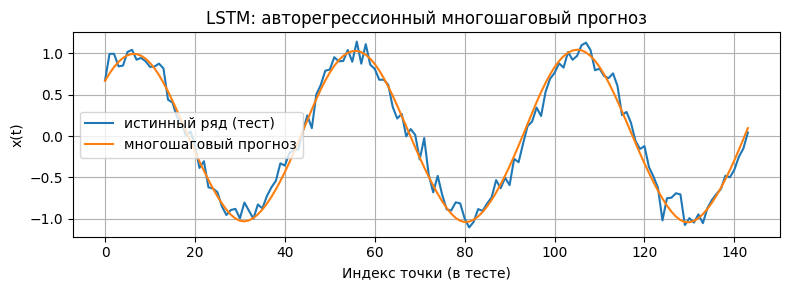

In [15]:
def multi_step_forecast(model, last_window, n_steps, device):
    model.eval()
    window = last_window.copy()
    preds = []
    with torch.no_grad():
        for _ in range(n_steps):
            x = torch.tensor(window, dtype=torch.float32).view(1, -1, 1).to(device)
            y_pred = model(x).cpu().numpy().flatten()
            y_scalar = float(y_pred[0])
            preds.append(y_scalar)
            window = np.roll(window, -1)
            window[-1] = y_scalar
    return np.array(preds)

# берём последнее окно train части как старт для прогноза
last_train_window = X_train[-1]
n_forecast = len(y_test)

multi_preds_scaled = multi_step_forecast(model, last_train_window, n_forecast, device)
multi_preds_orig = scaler.inverse_transform(multi_preds_scaled.reshape(-1, 1)).flatten()

plt.figure(figsize=(8, 3))
plt.plot(range(len(y_test_orig)), y_test_orig, label="истинный ряд (тест)")
plt.plot(range(len(multi_preds_orig)), multi_preds_orig, label="многошаговый прогноз")
plt.xlabel("Индекс точки (в тесте)")
plt.ylabel("x(t)")
plt.title("LSTM: авторегрессионный многошаговый прогноз")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
# num_epochs = 150

### Сравнение одношагового и многошагового прогноза

Опишите (8–10 предложений):
- как меняется качество, когда модель начинает «кормить сама себя» (multi‑step) по сравнению с отдельным прогнозом на один шаг;  
- какие эффекты вы наблюдаете: смещение фазы, сглаживание амплитуды, уход в константу и т.п.;  
- насколько эти эффекты совпадают с тем, что вы ожидали до эксперимента.


In [16]:
multi_step_comment = """По сравнению с одношаговым прогнозом, многошаговый выдает качество заметно хуже.
Модель начинает "кормить сама себя", поэтому предсказания постепенно начинают отклоняться от истинного ряда.
На графике видно, что пики и впадины начинают запаздывать относительно истинного ряда.
Также происзодит сглаживание апмплитуды: экстремумы меньше, чем в истинном ряде.
Еще можно наблюдать общее накопление ошибки, из-за чего к концу интервала расхождение становится сильнее, чем в начале.
Эффекта ухода в константу не наблюдается.
Однако тенденция к этому есть.
В целом так я и предполагала в самом начале: смещение фазы и сглаживание амплитуды.
"""
print(multi_step_comment)

По сравнению с одношаговым прогнозом, многошаговый выдает качество заметно хуже.
Модель начинает "кормить сама себя", поэтому предсказания постепенно начинают отклоняться от истинного ряда.
На графике видно, что пики и впадины начинают запаздывать относительно истинного ряда.
Также происзодит сглаживание апмплитуды: экстремумы меньше, чем в истинном ряде.
Еще можно наблюдать общее накопление ошибки, из-за чего к концу интервала расхождение становится сильнее, чем в начале.
Эффекта ухода в константу не наблюдается.
Однако тенденция к этому есть.
В целом так я и предполагала в самом начале: смещение фазы и сглаживание амплитуды.



## 8. Идеи для вариаций в вашей работе

В **своём** варианте вы должны:

- попробовать как минимум **две дополнительные** конфигурации гиперпараметров (например, `window_size`, `hidden_size`, `num_layers`, `num_epochs`) и сравнить кривые loss и качество прогноза;  
- описать, какие конфигурации дают наилучший баланс между плавностью кривых, скоростью сходимости и качеством многошагового прогноза;  
- сформулировать практические «правила» выбора окна и размеров модели для похожих задач.


In [18]:
final_summary = """
Я попробовала следующие конфигурация, меняла по одному гипераметру при каждом запуске:
window_size: 60 и 10
hidden_size: 8 и 128
num_layers: 2
num_epochs: 20 и 150.

Самые плохие показатели на многошаговом прогнозе были при параметрах window_size=10 и num_epochs=20.
На window_size=10 происходят следующие эффекты: смещение фазы, сглаживание амплитуды, уход в константу.
На num_epochs=20 происходят следующие эффекты: смещение фазы, сглаживание амплитуды.
Наиболее сглаженный, устойчивый прогноз показался при параметре window_size=60.
Однако он примерно похож на базовую модель.

Выбор окна стоит делать таким, чтобы он захватывал ключевые зависимости ряда, но не стоит делать его слишком большим.
Размер скрытого слоя увеличивать с сложностью данных, иначе может ухудшиться обобщение и устойчивость.
Размер num_layers для данной задачи достаточно 1, так как задача достаточно простая.

В целом должен быть баланс, все гиперпараметры должны быть хорошо подобраны между собой.
"""
print(final_summary)


Я попробовала следующие конфигурация, меняла по одному гипераметру при каждом запуске:
window_size: 60 и 10
hidden_size: 8 и 128
num_layers: 2
num_epochs: 20 и 150.

Самые плохие показатели на многошаговом прогнозе были при параметрах window_size=10 и num_epochs=20.
На window_size=10 происходят следующие эффекты: смещение фазы, сглаживание амплитуды, уход в константу.
На num_epochs=20 происходят следующие эффекты: смещение фазы, сглаживание амплитуды.
Наиболее сглаженный, устойчивый прогноз показался при параметре window_size=60.
Однако он примерно похож на базовую модель.  

Выбор окна стоит делать таким, чтобы он захватывал ключевые зависимости ряда, но не стоит делать его слишком большим.
Размер скрытого слоя увеличивать с сложностью данных, иначе может ухудшиться обобщение и устойчивость. 
Размер num_layers для данной задачи достаточно 1, так как задача достаточно простая.

В целом должен быть баланс, все гиперпараметры должны быть хорошо подобраны между собой.

